# **A Arquitetura _Transformer_**
<font size=3>

Nesta aula, daremos um salto fundamental no estudo de Processamento de Linguagem Natural, deixando para trás a sequencialidade estrita das Redes Neurais Recorrentes (RNNs) para explorar o modelo que revolucionou a área a partir do artigo científico [*"Attention Is All You Need"* (Vaswani et al., 2017)](https://arxiv.org/pdf/1706.03762). Ao longo deste notebook, não apenas estudaremos a teoria matemática por trás dos mecanismos de **Autoatenção** (*Self-Attention*) e **Atenção Múltipla** (*Multi-Head Attention*), mas construiremos, passo a passo e do zero, um tradutor **Português $\to$ Inglês** funcional utilizando a biblioteca **Keras** e o *dataset Anki*. O objetivo é desmistificar a "caixa preta" dos Grandes Modelos de Linguagem (LLMs) atuais, implementando cada componente — do *Embedding* Posicional à camada de projeção final — para entender profundamente como as máquinas processam contexto e dependências de longo prazo.

<font size=3><center>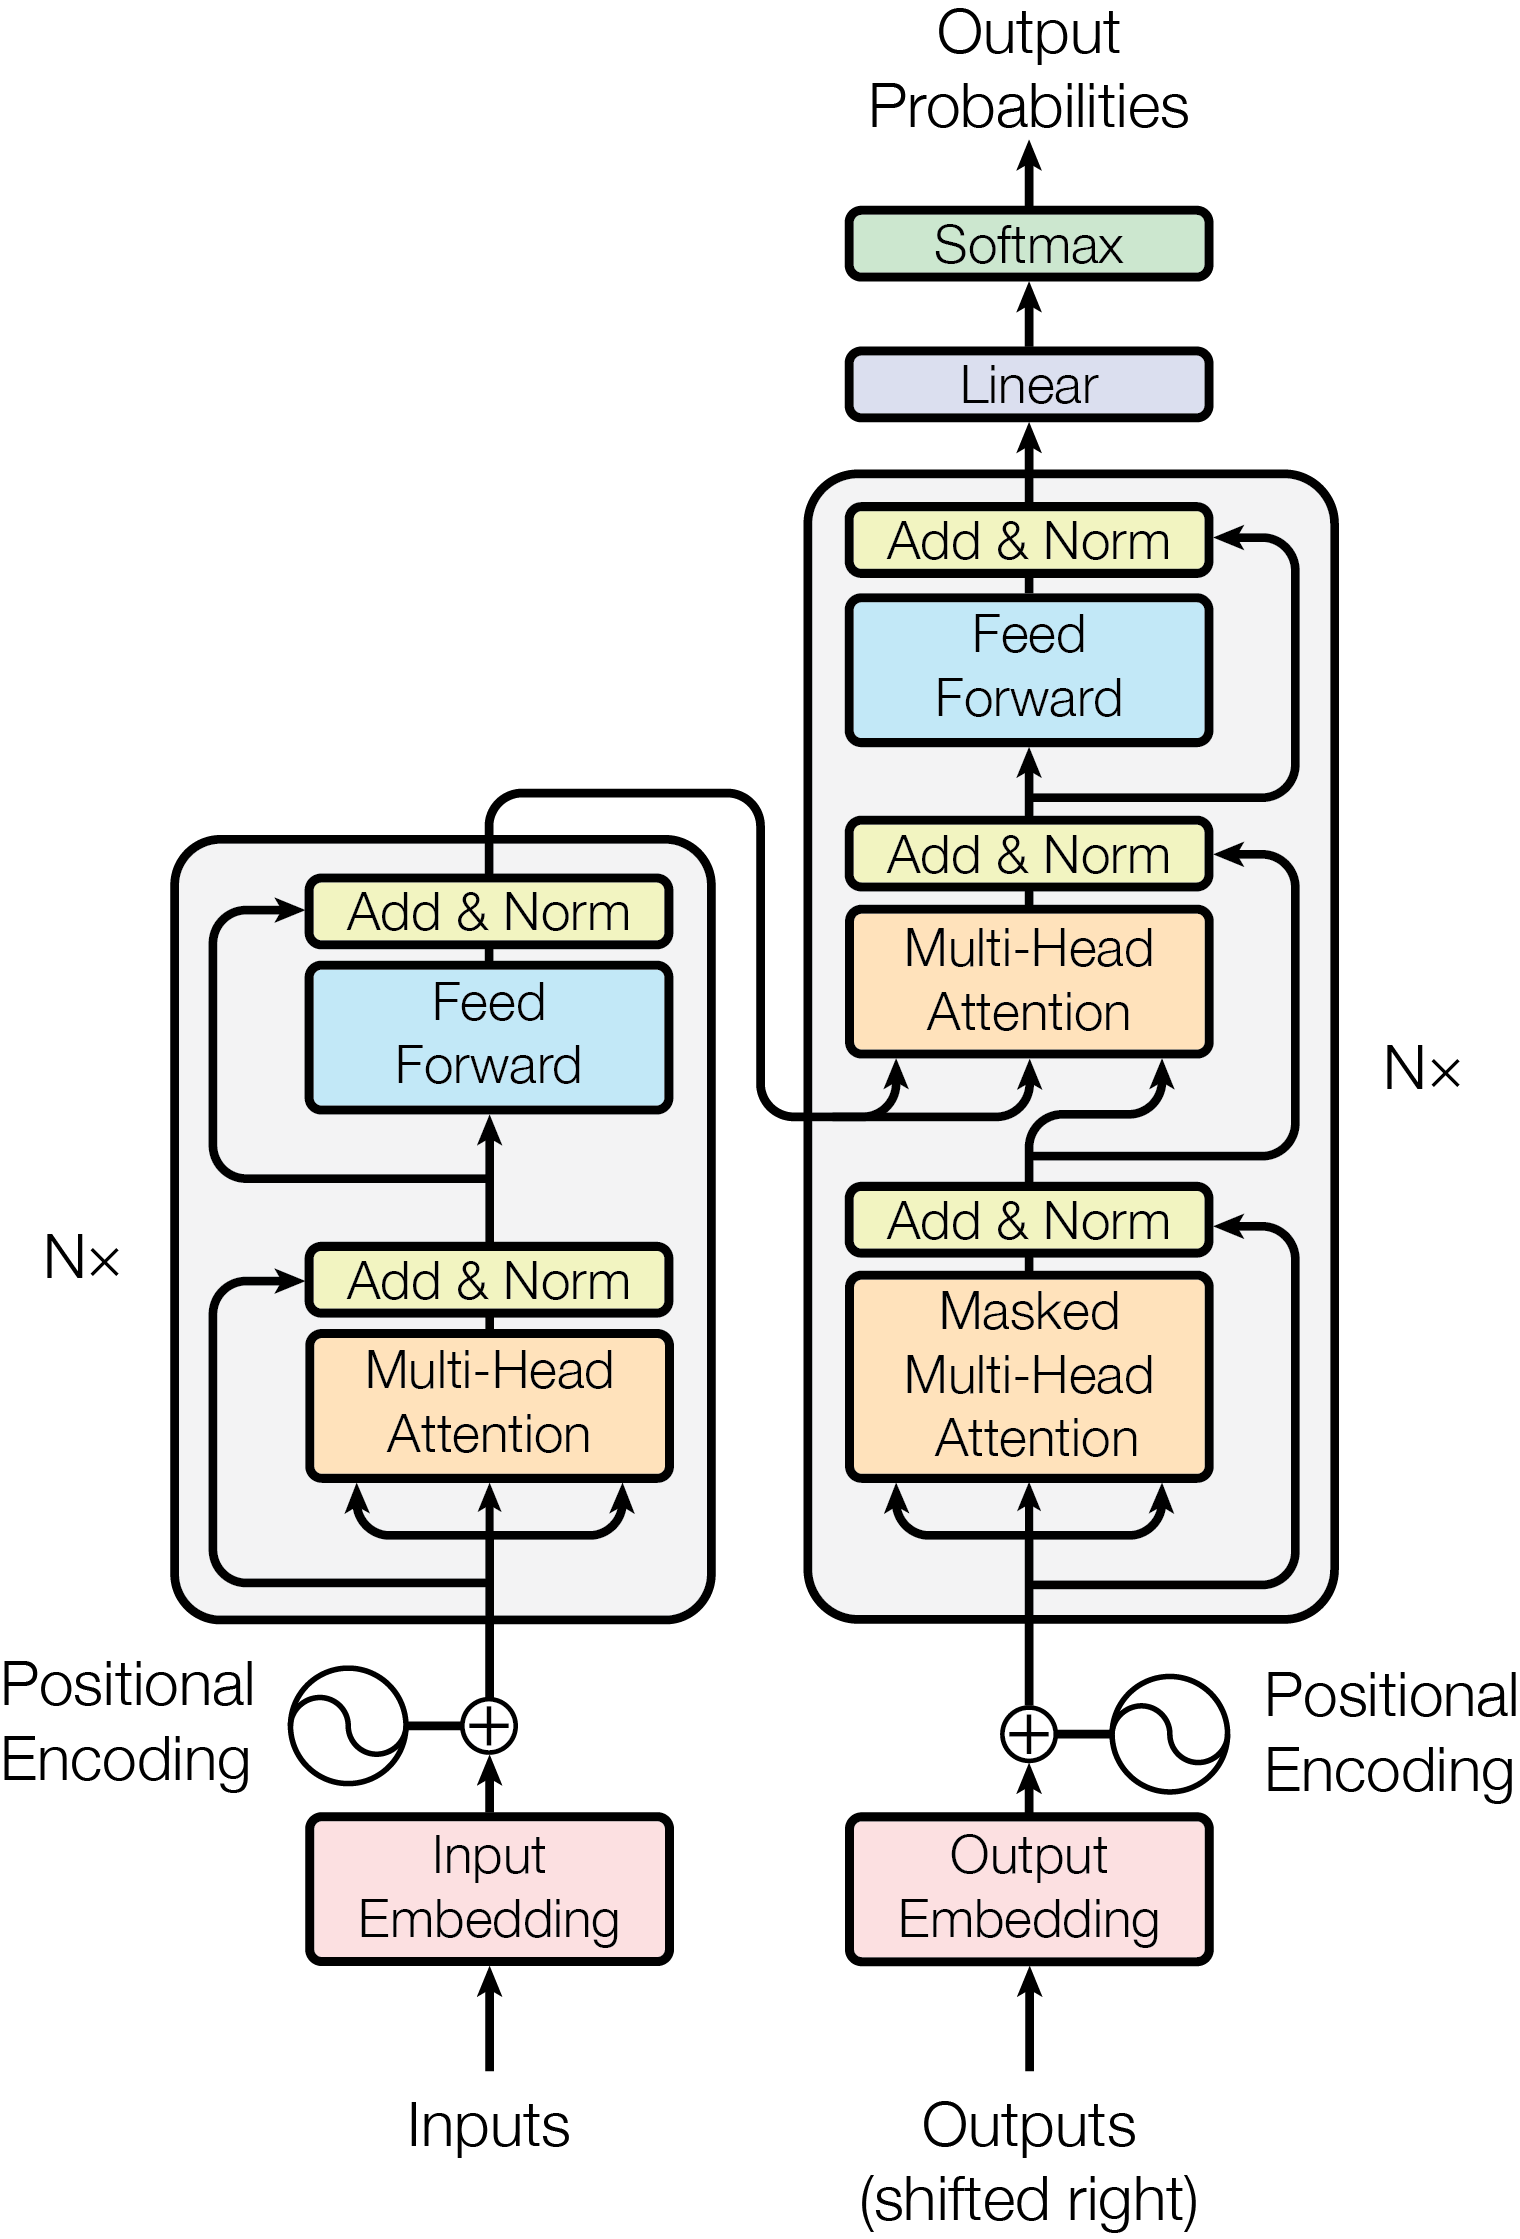</center></p><p style="text-align:center;"><em>Arquitetura Transformer (figura retirada do artigo).</em>

## **1. Introdução:**
<font size=3>

Até 2017, o estado da arte em Processamento de Linguagem Natural (NLP) era dominado por Redes Neurais Recorrentes (RNNs) e suas variantes mais robustas, como LSTM (*Long Short-Term Memory*) e GRU (*Gated Recurrent Unit*). Embora revolucionárias na época, essas arquiteturas processam dados de forma **sequencial**.

<font size=3>

Para ler uma frase, a rede precisa ler a palavra $x_1$, gerar um estado oculto $h_1$, passar esse estado para o próximo passo, ler $x_2$, e assim por diante. Desta forma, as limitações das redes recorrentes se tornam:
1. **Processamento serial (não paralelizável):** Como o estado $h_t$ depende estritamente de $h_{t-1}$, não podemos treinar a rede usando o poder massivo de paralelismo das GPUs modernas. Temos que esperar o passo anterior terminar.
   
2. **Memória de curto prazo:** Mesmo com LSTMs, à medida que a frase fica longa (ex: um parágrafo de um documento jurídico), a informação do início da frase se dilui ou se perde antes de chegar ao final.

3. **Gargalo de informação:** Em tarefas de tradução clássicas, todo o significado da frase de entrada precisava ser comprimido em um único vetor de contexto fixo.



### **1.1 O Mecanismo de Atenção (a mudança de paradigma):**
<font size=3>
    
A **arquitetura Transformer**, proposta por *Vaswani et al.*, descarta a recorrência. A ideia central é: **"E se, ao invés de processar palavra por palavra sequencialmente, o modelo pudesse olhar para a frase inteira de uma só vez?"**

O **Mecanismo de Atenção** permite que o modelo, ao processar uma palavra específica (como "banco"), olhe para todas as outras palavras da frase simultaneamente para entender o contexto (saber se é "banco" de sentar ou "banco" de dinheiro), atribuindo **pesos de importância** diferentes a cada palavra.

<font size=3><center>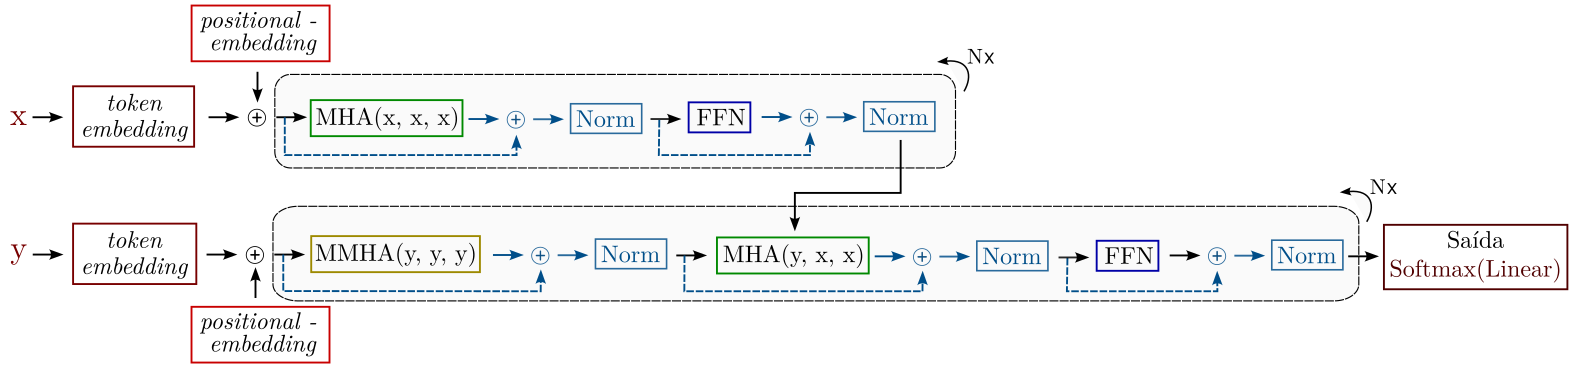</center></p><p style="text-align:center;"><em>Arquitetura Transformer.</em>

### **1.2. A tarefa _Sequence-to-Sequence_ (Seq2Seq):**
<font size=3>
    
Nesta aula, aplicaremos o Transformer na tarefa clássica de **Tradução Automática**.
Este é um problema *Seq2Seq*:
  * **Input:** Uma sequência de palavras em Português (comprimento $N$).
  * **Output:** Uma sequência de palavras em Inglês (comprimento $M$).

> **Nota:** $N$ e $M$ raramente são iguais. O modelo precisa aprender a alinhar conceitos, não apenas posições.

<font size=3>

**Exemplo de implementação com RNN:**
  
<font size=2>
    
```python
# definindo o codificador (encoder):
x1_in = keras.Input(shape=(1,), dtype=tf.string)

x = encoder_vectorizer(x1_in)

x = layers.Embedding(vocab_size_source, embed_dim)(x)

h = layers.SimpleRNN(latent_dim)(x)


# definindo o decodificador (decoder):
x2_in = keras.Input(shape=(1,), dtype=tf.string)

x = decoder_vectorizer(x2_in)

x = layers.Embedding(vocab_size_target, embed_dim)(x)


# o decoder recebe o estado final do encoder como sua inicialização (initial_state)
x = layers.SimpleRNN(latent_dim, return_sequences=True)(x, initial_state=h)

x_out = layers.Dense(vocab_size_target, activation="softmax")(x)


# definindo o modelo seq2seq:
model = keras.Model(inputs=[x1_in, x2_in], outputs=x_out, name="Seq2Seq")
```
<br>

<font size=3><center>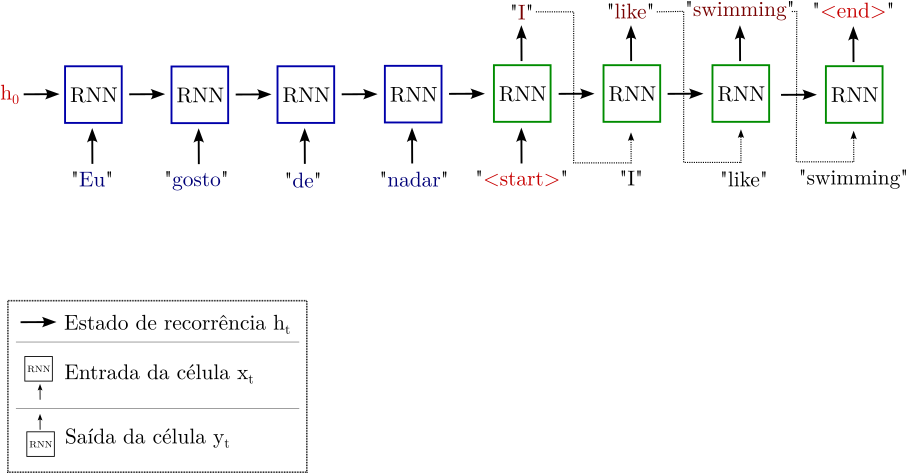</center>

<font size=3>

A figura acima, ilustra o processamento *seq2seq* com células RNN. Observe que os blocos azuis — a parte **codificadora** (*encoder*) da arquitetura — processa toda a entrada, enquanto os blocos verdes — a parte **decodificadora** (*decoder*) — processa a saída de forma iterativa.

Para que o *decoder* possa realizar a saída do primeiro *token* corretamente ("I"), sua entrada inicial processa o *token* especial $\texttt{[start]}$. Já, para que o modelo saiba quando parar no momento correto, seu treinamento o leva a retornar o *token* especial $\texttt{[end]}$.

> Este processe de tradução, analogamente, será desenvolvido aqui com base na arquitetura Transformer (ilustrado abaixo).

<font size=3><center>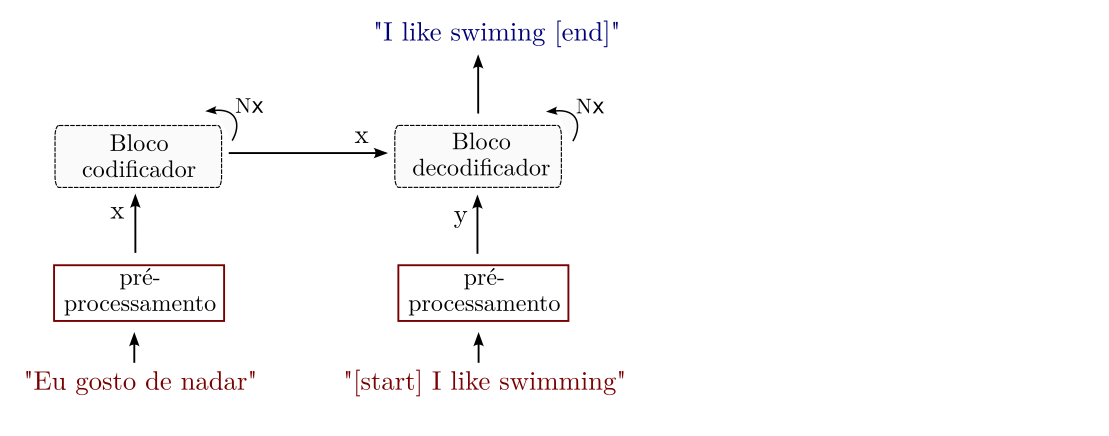</center>

### **1.3 _Dataset_ de tradução:**
<font size=3>
    
Utilizaremos o *dataset* do projeto [Tatoeba/Anki](https://www.manythings.org/anki/), também disponível no diretóri $\texttt{dataset/}$ do *Drive*, que contém pares de frases curtas e diretas. Vamos carregar os dados agora para inspecionar o que nosso modelo terá que aprender.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("./dataset/por-eng.csv")
#df = pd.read_csv("/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/3-unidade/dataset/por-eng.csv")
print(df.shape)
df.head()

(196620, 2)


,por,eng
0,Vai.,Go.
1,Vá.,Go.
2,Oi.,Hi.
3,Corre!,Run!
4,Corra!,Run!


In [4]:
# aplicando os tokens especiais para começo e parada da sentença em inglês
df["eng"] = df["eng"].apply(lambda x: "[start] " + x + " [end]")

# embaralhamento das amostras:
text_pairs = df.sample(frac=0.1,).to_numpy() # AMOSTRAGEM REDUZIDA

print(text_pairs.shape)
text_pairs[0]

(19662, 2)


array(['Por que os senhores estão a perguntar?',
       '[start] Why do you ask? [end]'], dtype=object)

In [5]:
# dividindo os dados entre treinamento, validação e teste:
n_samples = text_pairs.shape[0]

n_train = int(0.7*n_samples)
n_val = int(0.2*n_samples)

assert n_train + n_val < n_samples, "Proporção de separação inválida!"

train_pairs = text_pairs[:n_train]
val_pairs = text_pairs[n_train:n_train + n_val]
test_pairs = text_pairs[n_train + n_val:]

print(f"train:{train_pairs.shape}, val:{val_pairs.shape}, test:{test_pairs.shape}")

train:(13763, 2), val:(3932, 2), test:(1967, 2)


In [6]:
# apagando objetos desnecessários:
del df, text_pairs

## **2. A entrada do modelo (vetorização e posicionamento):**
<font size=3>
    
Para que o Transformer funcione, precisamos realizar três transformações nos dados:
- **Tokenização e Indexação:** Converter strings em sequências de números inteiros (índices).
- **_Word-embedding_):** Converter índices inteiros em vetores densos de significado.
- **_Positional Encoding_ (_embedding_):** Injetar informação sobre a posição de cada palavra na frase.


<font size=3><center>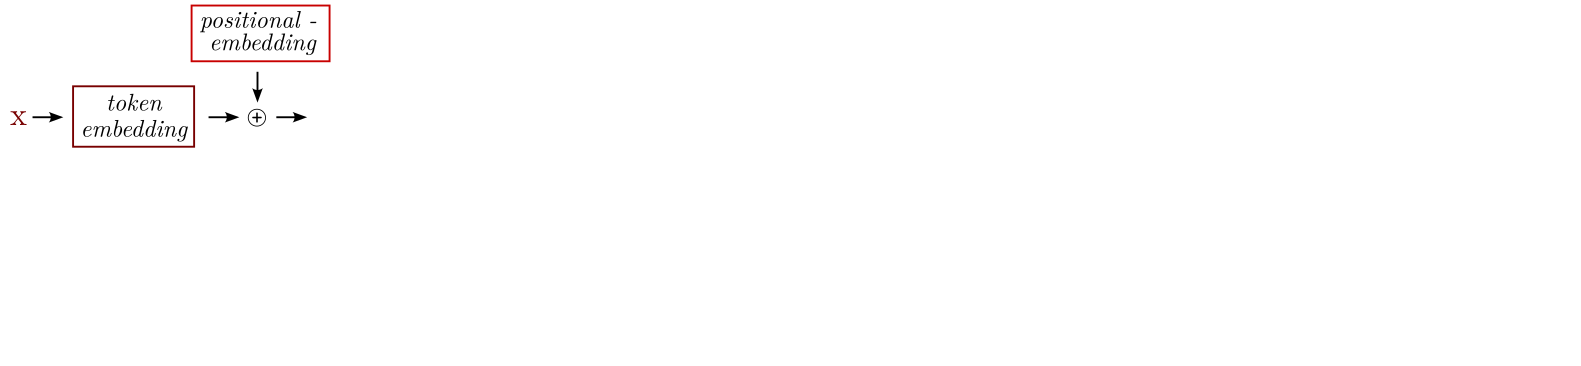</center></p><p style="text-align:center;"><em>Vetorização + posicionamento.</em>

### **2.1 Pré-processamento e vetorização:**
<font size=3>
    
Definiremos alguns hiperparâmetros cruciais:
 * `vocab_size`: Tamanho do vocabulário (limitaremos às 5.000 palavras mais comuns).
 * `max_len`: Tamanho máximo das frases (padronizaremos para 16 tokens).

> **Atenção:** Para o texto em Inglês (alvo), precisamos de uma padronização customizada. Por padrão, o Keras remove caracteres especiais. Se não configurarmos isso, ele removerá nossos tokens `[start]` e `[end]`, quebrando o modelo.


In [7]:
import tensorflow as tf
from keras import layers

In [8]:
# hiperparâmetros:
vocab_size = 5000
max_len = 16
embed_dim = 32
batch_size = 64

def Preprocessor(x): # remove tudo que não for alfanumérico, exceto colchetes
    x = tf.strings.lower(x)
    return tf.strings.regex_replace(x, r"[^\w\s\[\]]", "")

# vetorização da fonte (português):
source_vec = layers.TextVectorization(max_tokens=vocab_size,
                                      output_mode="int",
                                      output_sequence_length=max_len)

# vetorização do alvo (inglês):
target_vec = layers.TextVectorization(standardize=Preprocessor,
                                      max_tokens=vocab_size,
                                      output_mode="int",
                                      output_sequence_length=max_len + 1) # "+1" para comportar a entrada do token "[start]"


# adaptando ao vocabulário de treino:
source_vec.adapt([pair[0] for pair in train_pairs])
target_vec.adapt([pair[1] for pair in train_pairs])

vocab_por = source_vec.get_vocabulary()
vocab_eng = target_vec.get_vocabulary()

for por, eng in zip(vocab_por[:10], vocab_eng[:10]):
    print(f"{por:^5} | {eng:^5}")


      |      
[UNK] | [UNK]
 tom  | [start]
 que  | [end]
  o   |  tom 
 não  |   i  
 eu   |  to  
 de   |  you 
  a   |  the 
você  |   a  


2026-06-10 19:29:03.727649: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-06-10 19:29:03.727671: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-10 19:29:03.727675: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1781130543.727687 8379082 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1781130543.727713 8379082 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<font size=3>
<br>
    
Para garantir eficiência, criaremos um pipeline que carrega, vetoriza e agrupa os dados em *batches*.

In [9]:
def format_dataset(por, eng):

    por = source_vec(por)
    eng = target_vec(eng)

    return ({"source": por,           # entrada do Encoder recebe Português
             "target": eng[:, :-1]},  # entrada Decoder recebe Inglês (sem o token [end])
            eng[:, 1:])               # o alvo é o Inglês deslocado (sem o token [start])

def make_dataset(pairs):

    por_texts, eng_texts = zip(*pairs)

    dataset = tf.data.Dataset.from_tensor_slices((list(por_texts), list(eng_texts)))

    dataset = dataset.batch(batch_size) # dividindo os dados em lotes (batches)
    dataset = dataset.map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE) # paralelização do genador

    # cache: armazena todo o pré-processamento no disco para que, acada época, o gerador faça seu trabalho;
    # shuffle: embaralha os dados em janelas (buffers) de tamanho 2048 para melhor armazenamento de memória;
    # prefetch: equanto a GPU usa um lote para treinar, a CPU (em paralelo) prepara os próximos 16 lotes.
    return dataset.cache().shuffle(2048).prefetch(16)

train_dset = make_dataset(train_pairs)
val_dset   = make_dataset(val_pairs)

example_batch = next(iter(train_dset))
inputs, targets = example_batch

print(f"Shape do Encoder Input (Português): {inputs['source'].shape}")
print(f"Shape do Decoder Input (Inglês):    {inputs['target'].shape}")
print(f"Shape do Label Real (Inglês):       {targets.shape}")

Shape do Encoder Input (Português): (64, 16)
Shape do Decoder Input (Inglês):    (64, 16)
Shape do Label Real (Inglês):       (64, 16)


### **2.2 O _embedding_ posicional:**
<font size=3>
    
Aqui reside a maior diferença conceitual do Transformer. Uma RNN sabe que "eu" vem antes de "fui" porque ela processa "eu" no tempo $t=1$ e "fui" no tempo $t=2$. O Transformer processa tudo ao mesmo tempo (em paralelo). Para ele, uma frase é apenas um "saco de palavras".

Sem informação de posição, as frase
>  "o cachorro mordeu o homem"\
>  "o homem mordeu o cachorro"   

teriam representações idênticas na camada de atenção.

A solução é a **_embedding_ posicional** (*positional embedding* — PE). Nós somamos ao vetor da *embedding* um vetor de posição. Abaixo, um exemplo da operação para $\text{embed-dim} = 1$:
$$
    \underbrace{[0.46,\, 0.38,\, 0.23,\, 0.51]}_\text{word-embedding} + \underbrace{[0.0,\, 0.1,\, 0.2,\, 0.3]}_\text{positional embedding} = [0.46,\, 0.48,\, 0.43,\, 0.81]
$$

No artigo, os autores propuseram o uso de funções trigonométricas (seno e cosseno) de frequências variadas:
\begin{align}
    PE(x,\, 2\,i) &= \sin\left(\frac{x}{10000^{2i/d_{model}}}\right)  \, :\; \text{par}\\
    PE(x,\,2\,i+1) &= \cos\left(\frac{x}{10000^{2i/d_{model}}}\right) \, :\; \text{ímpar}
\end{align}
onde $i$ é o índice da posição do elemento $x \in [0,\, L)$, para $L \equiv \text{max-len}$. Isso cria um padrão geométrico único para cada posição que o modelo consegue aprender facilmente.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Exemplo de plotes de vetorização para max-len = 256 e embed-dim = 512:



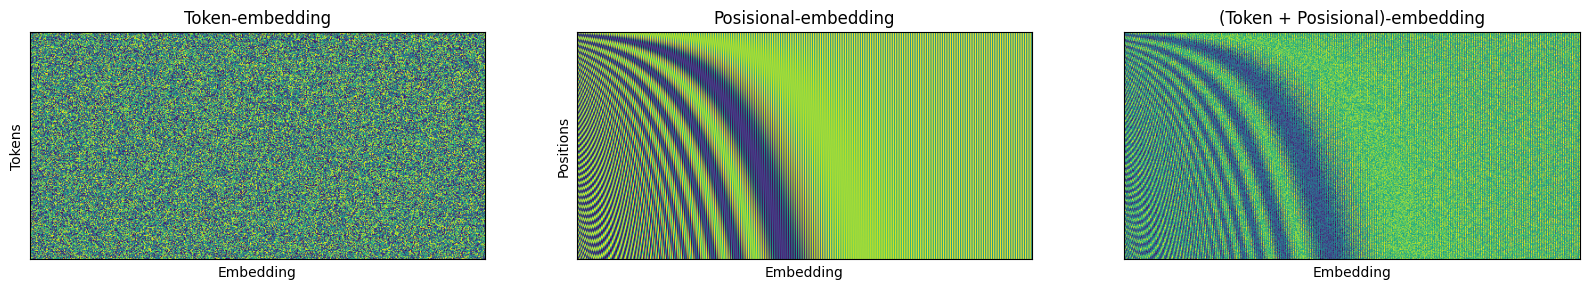

In [11]:
def sinusoidal_PE(max_len, d_model):

    x = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]

    # Obs.: na fórmula temos 1/10000^(2i/d_model), mas iremos usar 2*(i//2) para
    # garantir que índices pares e ímpares (2i e 2i+1) compartilhem o mesmo denominador
    # de frequência, i.e., i=[0, 1, 2, 3, 4, 5] → 2*(i//2) = [0, 0, 2, 2, 4, 4].
    f = x/np.power(10000, (2*(i//2))/np.float32(d_model))

    f[:, 0::2] = np.sin(f[:, 0::2]) # parte par
    f[:, 1::2] = np.cos(f[:, 1::2]) # parte ímpar

    return f


# Para visualizarmos os plotes de vetorização com melhor definição, vamos
# considerar multiplicar os valores de max_len e embed_dim por n:
n = 16

# definindo o embedding positional:
PE = sinusoidal_PE(n*max_len, n*embed_dim)

# simulando o token-embedding:
TE = tf.random.uniform((n*max_len, n*embed_dim))

print(f"Exemplo de plotes de vetorização para max-len = {n*max_len} e embed-dim = {n*embed_dim}:\n")

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].set_title("Token-embedding")
axs[0].imshow(TE)
axs[0].set_ylabel("Tokens")

axs[1].set_title("Posisional-embedding")
axs[1].imshow(PE)
axs[1].set_ylabel("Positions")

axs[2].set_title("(Token + Posisional)-embedding")
axs[2].imshow(TE + PE)

for ax in axs:
    ax.set_xlabel("Embedding")
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

<font size=3>
    
> **Nota** Na implementação original do paper, eles usam senos e cossenos fixos. No entanto, implementações modernas (como no BERT e GPT) frequentemente usam `layers.Embedding` para a posição também, deixando a rede *aprender* a melhor representação posicional. Por simplicidade didática iremos usar a abordagem moderna.

In [12]:
class PositionalEmbedding(layers.Layer):

    def __init__(self, max_len, input_dim, output_dim):
        super().__init__()

        self.token_embeddings = layers.Embedding(input_dim=input_dim,
                                                 output_dim=output_dim)

        self.position_embeddings = layers.Embedding(input_dim=max_len,
                                                    output_dim=output_dim)

        self.max_len = max_len
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):

        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)

        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)

        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        """
        Por causa do padding, muitas entradas podem conter o número 0.
        Para evitar que o modelo preste atenção neste token vazio, esta função
        irá mascará-lo, colocando "True" e "False" para entradas diferentes e
        igual a zero.
        """
        return tf.math.not_equal(inputs, 0)



In [13]:
# considere as sentenças exemplo do dataset:
text_por = "ela sabe andar de skate"
text_eng = "[start] she can skate [end]"

# indexação:
ids_por = source_vec([text_por])
ids_por

<tf.Tensor: shape=(1, 16), dtype=int64, numpy=
array([[  45,   63,  668,    7, 2576,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0]])>

In [14]:
PE = PositionalEmbedding(max_len, vocab_size, embed_dim)

x_por = PE(ids_por)

print(x_por.shape)

(1, 16, 32)


## **3. O Mecanismo de Atenção**:
<font size=3>
    
Se as RNNs leem uma frase palavra por palavra, o Mecanismo de Atenção permite que o modelo olhe para **todas as palavras ao mesmo tempo** e decida quais são importantes para entender a palavra atual.


<font size=3><center>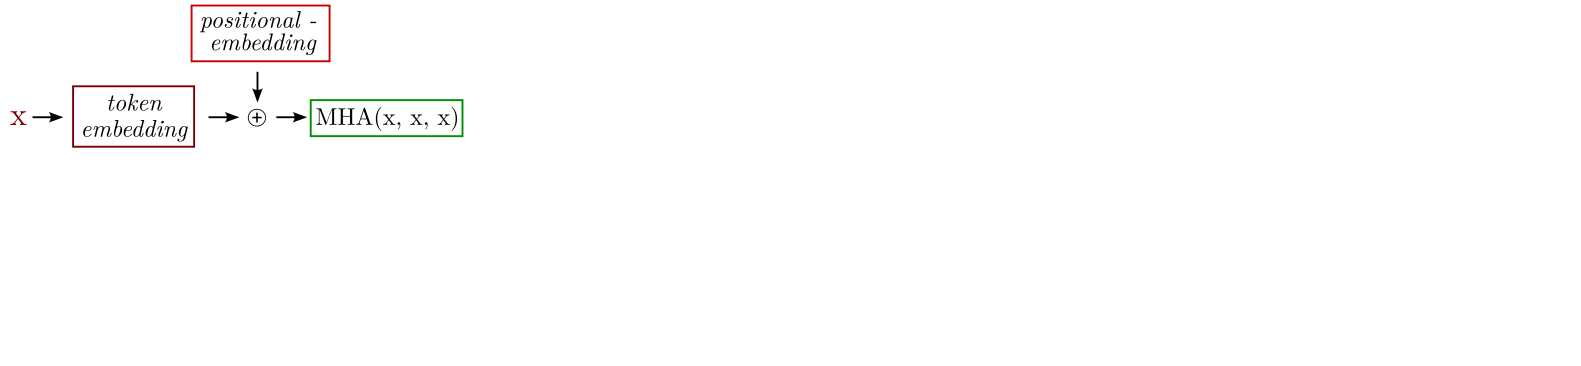</center></p><p style="text-align:center;"><em>Camada Multi-Head Attention (MHA).</em>

### **3.1 A intuição (_Query_, _Key_ e _Value_):**
<font size=3>
    
Para calcular a **atenção**, o Transformer cria três vetores diferentes para cada palavra da frase. A nomenclatura vem de sistemas de recuperação de informação (bancos de dados):
1. **_Query_ ($Q$ - pergunta):** O que eu (a palavra atual) estou procurando?
2. **_Key_ ($K$ - chave):** O que eu (as outras palavras) tenho a oferecer? Serve para identificação.
3. **_Value_ ($V$ - valor):** Qual é o meu conteúdo real?

**A Analogia:** Imagine que você está numa biblioteca (o texto).
  * Você tem uma pergunta (**_query_**): "Livros sobre Redes Neurais".
  * Você olha as etiquetas (**_keys_**).
  * Quando a etiqueta ($K$) é similar à sua pergunta ($Q$), você pega o conteúdo do livro (**_value_**).
  * Se a etiqueta for "Livros de Culinária", a similaridade é baixa, e você ignora aquele conteúdo.
    

### **3.2 A matemática (_dot-product_):**
<font size=3>
    
Como calculamos essa "similaridade" matematicamente? Usando o **produto escalar**. Se dois vetores apontam para a mesma direção, seu produto escalar é alto. A fórmula fundamental da **atenção** é dada por:
$$
    \text{Attention}(Q,\, K,\, V) = \text{Softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_k}}\right) \cdot V \, ,
$$
onde:
- $\{Q,\, K,\, V\} \in \mathbb{R}^{L,\, d_k}$: Definimos $d_k$ como a dimensão da chave (ou a dimensão da *atenção*).
- $(Q \cdot K^T) \in \mathbb{R}^{L,\, L}$: Calcula a similaridade entre a pergunta e todas as chaves. Resulta em uma matriz de "_scores_".
- $(\sqrt{d_k})$: Fator de escala para evitar que os valores fiquem muito grandes (o que "mataria" os gradientes na Softmax).
- $(\text{Softmax})$: Converte os scores em probabilidades.
- $(\;\cdot V)$: Multiplica os pesos pelo conteúdo ($V$).
- $\text{Attention}(Q,\, K,\, V) \in \mathbb{R}^{L,\,d_k}$: Retorna o grau (probabilidade) de *atenção* dos *tokens* codificados em $V$.

> **Observação:** Se o produto escalar $Q\cdot K^T$ forma a matriz *scores*, dizemos que $\text{Softmax}\left(Q\cdot K^T/\sqrt{d_k}\right)$ forma os **pesos** (*weights*) da Atenção: algo como **o grau de atenção ao vetor _value_ ($V$)**.


### **3.4 Atenção Multi-Cabeça (_multi-head attention_):**
<font size=3>

Uma única camada de atenção pode focar em apenas um aspecto da frase (ex: quem realizou a ação). Mas a linguagem é complexa. Precisamos entender tempo verbal, gênero, referências, etc.

A solução é o **_Multi-Head Attention_ (MHA)**. Dividimos os vetores $Q$, $K$ e $V$ em $h$ partes ("cabeças"). Cada cabeça processa uma subparte do vetor independentemente e, no final, concatenamos tudo. Isso permite que o modelo aprenda múltiplas relações simultâneas.

>**Analogia:** Imagine uma sala de creche agitada com 20 crianças. Se houver apenas um adulto supervisionando (uma única cabeça de atenção), ele terá uma visão genérica e "saturada", focando apenas no evento mais barulhento do momento. Detalhes sutis seriam perdidos.
>
>Para ajudar nessa missão, colocaremos mais monitores ("cabeças") para observarem quem está brincando, quem está brigando e quem está correndo, a fim de aumentar o nível de atenção global na sala.

Matematicamente, a camada MHA é definida como,
$$
    MHA(q,\, k,\, v) = \text{Concat}\left[\text{Attention}_i\left(q\cdot W_i^Q,\, k\cdot W_i^K,\, v\cdot W_i^V\right)\right]\cdot W^O  \, ,\quad i \in [1,\, h] \, ,
$$
onde definimos as entradas $\{q,\, k,\, v\} \in \mathbb{R}^{L,\, d_m}\;$ têm a dimensão da vetorização (aqui, temos $d_k \equiv d_m/h$), tal que
\begin{align}
    Q &\equiv q\cdot W^Q \, ,\\
    K &\equiv k\cdot W^K \, ,\\
    V &\equiv v\cdot W^V \, ,
\end{align}
para $\{W^Q,\, W^K,\, W^V\} \in \mathbb{R}^{d_m,\, d_k}$, corroboramos que $\{Q,\, K,\, V\} \in \mathbb{R}^{L,\, d_m}$. Como a concatenação nos dá $\text{Concat}[\;\cdot\;] \in \mathbb{R}^{L,\, h\cdot d_k}$, a matriz peso $W^O \in \mathbb{R}^{h\cdot d_k,\, d_m}$ integra os resultados em uma projeção no espaço de mesma dimensionalidade das entradas. Assim, **as entradas e saída desta camada tem o mesmo formato** ($\text{MHA} \in \mathbb{R}^{L,\,d_m}$), o que é crucial para pudermos encadear camadas deste tipo.

>**Observe** na figura acima, que as entradas ($x \equiv q = k = v$) é, de fato, o vetor resultante da vetorização. Neste caso, dizemos que esta camada realiza o mecanismo de **auto-atenção (_self-attention_)**.


In [15]:
class MultiHeadAttention(layers.Layer):

    def __init__(self, d_model, num_heads, return_weights=False):
        super().__init__()

        self.h = num_heads
        self.d_m = d_model

        assert d_model % num_heads == 0 # d_m deve ser divisível pelo número de cabeças

        self.d_k = d_model//num_heads

        self.scaler = tf.math.sqrt(tf.cast(self.d_k, tf.float32))

        self.return_weights = return_weights

        # camadas lineares para projeção (q·W^Q, k·W^K, v·W^V):
        self.proj_q = layers.Dense(d_model)
        self.proj_k = layers.Dense(d_model)
        self.proj_v = layers.Dense(d_model)

        # camada linear da saída (W^O):
        self.proj_o = layers.Dense(d_model)

        # avisando ao Keras que esta classe suporta máscaras:
        self.supports_masking = True


    def split_heads(self, x, batch_size):
        """
        Divide a última dimensão em (h, d_k).
        Transpõe o resultado para shape (batch_size, h, L, d_k)
        """

        x = tf.reshape(x, (batch_size, -1, self.h, self.d_k))

        return tf.transpose(x, perm=[0, 2, 1, 3])


    def attention(self, Q, K, V, mask=None):

        scores = tf.matmul(Q, K, transpose_b=True)/self.scaler

        # Mask: se houver máscara, somamos um número muito negativo (-1e9)
        # para que a softmax zere essas posições, i.e., obter zero atenção
        # em casos especiais.
        if mask is not None:
            # a máscara entra como (batch, L), mas "scores" é (batch, h, L, L),
            # logo, faremos mask -> (batch, 1, 1, L)
            mask = tf.cast(mask, dtype=tf.float32)

            scores += (1 - mask)*(-1e9)

        weights = tf.nn.softmax(scores, axis=-1)

        output = tf.matmul(weights, V)

        return output, weights


    def call(self, q, k, v, mask=None):

        batch_size = tf.shape(q)[0]

        # projeções lineares:
        Q = self.proj_q(q)   # (batch_size, L, d_m)
        K = self.proj_k(k)   # (batch_size, L, d_m)
        V = self.proj_v(v)   # (batch_size, L, d_m)

        # dividindo em múltiplas cabeças:
        # transformação (batch, L, d_m) -> (batch, h, L, d_k), onde d_k = d_m/h
        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        # calculando em paralelo toadas as cabeças de atenção:
        scaled_attention, attention_weights = self.attention(Q, K, V, mask)
        # scaled_attention -> (batch, h, L, d_k)
        # attention_weights -> (batch, h, L, L)

        # reshape da "concatenação:"
        # primeiro transpomos de volta -> (batch, L, h, d_k)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

        # depois "achatamos" as duas últimas dimensões para voltar a ser d_m:
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_m))

        # projeção final:
        output = self.proj_o(concat_attention)

        if self.return_weights: return output, attention_weights
        else: return output


In [16]:
num_heads = 4

MHA = MultiHeadAttention(embed_dim, num_heads, return_weights=True)

print(f"x-in: {x_por.shape}")

x, weights = MHA(x_por, x_por, x_por)

print(f"x-out:{x.shape}, weights:{weights.shape}")

x-in: (1, 16, 32)
x-out:(1, 16, 32), weights:(1, 4, 16, 16)


<font size=3>

No Keras, não precisamos implementar a classe do zero manualmente (embora seja possível). A camada [`MultiHeadAttention`](https://keras.io/api/layers/attention_layers/multi_head_attention/) já implementa a divisão das cabeças, o cálculo escalar e a projeção final de forma otimizada:

<font size=2>
    
>```python
>MHA = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
>
># O parâmetro 'return_attention_scores=True' é útil para visualização,
># mas no treino real ele deve ser False para economizar memória.
>output_tensor, weights = MHA(query=temp_q, value=temp_v, key=temp_k,
>                             return_attention_scores=True)
>
>
>```

<font size=3>
<br>
    
Abaixo, um *heatmap* dos pesos da correlação *token* a *token*. Como as linhas somam 1, isso nos diz "quanto" a palavra da linha prestou atenção na palavra da coluna.

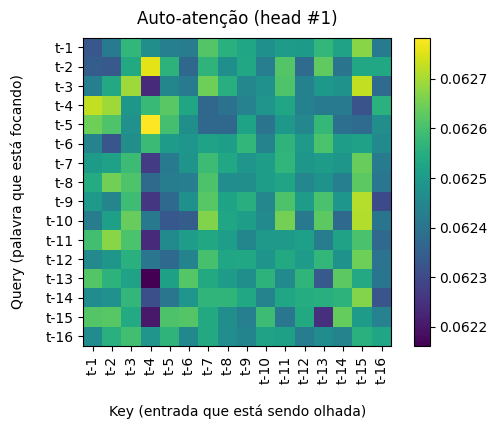

In [17]:
tokens = [f"t-{i+1}" for i in range(max_len)]

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

plt.title("Auto-atenção (head #1)", pad=10)

cax = ax.matshow(weights[0, 0], cmap='viridis')
fig.colorbar(cax)

ax.set_xticks(np.arange(len(tokens)))
ax.set_yticks(np.arange(len(tokens)))
ax.set_xticklabels(tokens, rotation=90)
ax.set_yticklabels(tokens)

ax.xaxis.set_ticks_position('bottom')

plt.xlabel("Key (entrada que está sendo olhada)", labelpad=15)
plt.ylabel("Query (palavra que está focando)", labelpad=15)
plt.show()

<font size=3>

**Observação:** os valores no *heatmap* são meramente ilustrativos, já que os parâmetros internos do modelo ainda não foram ajustados durante o treinamento.


### **3.5 A máscara de preenchimento:**
<font size=3>

Na implementação do `MultiHeadAttention` você deve ter notado um bloco condicional que aplica uma **máscara** (`mask`) à matriz `scores`:

<font size=2>

```python
    def attention(self, Q, K, V, mask=None):

        scores = tf.matmul(Q, K, transpose_b=True)/self.scaler
    
        # Mask: se houver máscara, somamos um número muito negativo (-1e9)
        # para que a softmax zere essas posições, i.e., obter zero atenção
        # em casos especiais.
        if mask is not None:
            # a máscara entra como (batch, L), mas "scores" é (batch, h, L, L),
            # logo, faremos mask -> (batch, 1, 1, L)
            mask = tf.cast(mask, dtype=tf.float32)
            
            if len(mask.shape) == 2:
                mask = mask[:, tf.newaxis, tf.newaxis, :]
                
            scores += (1 - mask)*(-1e9)
    
        weights = tf.nn.softmax(scores, axis=-1)
    
        output = tf.matmul(weights, V)

        return output, weights
```
<br>

<font size=3>

Esses "*casos especiais*", em que precisamos de **atenção nula**, ocorrem em duas situações:
 1. **Máscara de preenchimento (_padding mask_):** quando uma sentença indexada é preenchida com zeros (*token* vazio " ") para que ela tenha o comprimento da entrada do modelo (`max_len`);
 2. **Máscara causal (_causal mask_):** quando precisamos esconder o "próximo *token*" da sequência de predição. Esta será explicada mais a frente.

Para que o modelo não dê atenção a _tokens_ vazios, precisamos que a entrada da função **_Softmax_** seja um número infinitamente negativo ($-\infty$), o que na prática usamos $\approx -10^9$, já que
$$
    \lim_{x \to -\infty} \text{Softmax(x)} = \lim_{x \to -\infty} e^{x} = 0 \, .
$$

<br>

Assim, a frase **"_ela sabe andar de skate_"**, levará os seguintes resultados de processamento:

In [18]:
text_padded = text_por + (max_len - len(text_por.split()))*" [pad]"
text_padded

'ela sabe andar de skate [pad] [pad] [pad] [pad] [pad] [pad] [pad] [pad] [pad] [pad] [pad]'

In [19]:
tokens = text_padded.split()

for ID, token in zip(ids_por[0], tokens):
    print(f"{int(ID):^5}: {token:^10}")


 45  :    ela    
 63  :    sabe   
 668 :   andar   
  7  :     de    
2576 :   skate   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   
  0  :   [pad]   


In [20]:
def padding_mask(x):
    # verifica onde a sequência é diferernte de zero:
    x = tf.cast(tf.math.not_equal(x, 0), tf.float32)

    # Adiciona dimensões extras para que a máscara possa ser transmitida
    # pelas dimensões de Cabeças (Heads) e Queries da Atenção.
    # formato final -> batch_size, 1, 1, max_len)
    return x[:, tf.newaxis, tf.newaxis, :]

mask = padding_mask(ids_por)

print("Formato da máscara:", mask.shape, "\n")
print("Visualização da máscara:")
print(mask[0, 0, 0, :].numpy())

Formato da máscara: (1, 1, 1, 16) 

Visualização da máscara:
[1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


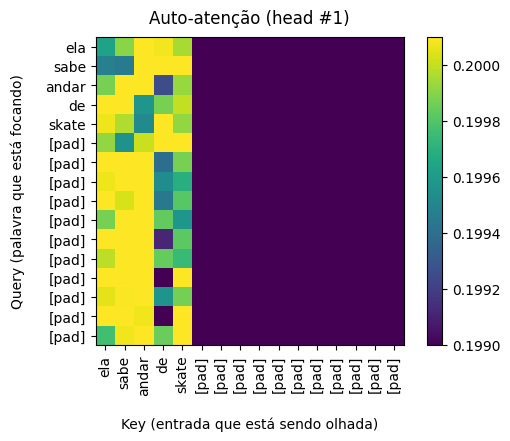

In [21]:
# aplicando a máscara de preenchimento no MultiHeadAttention:
_, weights = MHA(x_por, x_por, x_por, mask)


# visualização:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

plt.title("Auto-atenção (head #1)", pad=10)

cax = ax.matshow(weights[0, 0], vmin=0.199, vmax=0.2001)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(tokens)))
ax.set_yticks(np.arange(len(tokens)))
ax.set_xticklabels(tokens, rotation=90)
ax.set_yticklabels(tokens)

ax.xaxis.set_ticks_position('bottom')

plt.xlabel("Key (entrada que está sendo olhada)", labelpad=15)
plt.ylabel("Query (palavra que está focando)", labelpad=15)
plt.show()

<font size=3>

**Observe** no *heatmap* acima que:
 - **Eixo X (_keys_)** representa "*quem está sendo olhado*";
 - **Eixo Y (_queries_)** representa "*quem está olhando*".
   
Então, a **atenção é nula** (cor mais excura) quando o preenchimento ocorrem em "quem está sendo olhado".

## **4. Estabilidade numérica:**
<font size=3>

As redes profundas, em geral, sofre do problema do **desaparecimento do gradiente** (*gradient vanishing*), causado pela multiplicação sucessivas derivadas de valores pequenos. Como forma de superar esse problema, utilizamos estratégias como a **normalização**, **adequeção de função de ativação** e **conexões residuais** (*skip connections*).

<font size=3><center>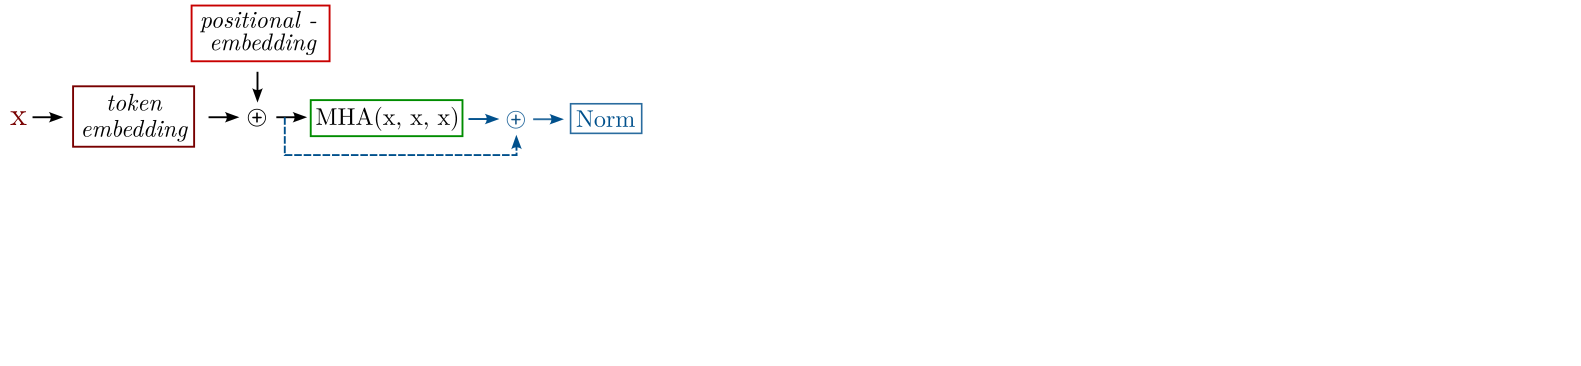</center></p><p style="text-align:center;"><em>A conexão residual.</em>

### **4.1 Conexões residuais:**
<font size=3>

Aqui, iremos somar a entrada da camada com sua saída,
$$
    x \;\rightarrow\; x + \text{Sublayer}(x)  \, ,
$$
de modo que o gradiente é "desobistruído" durante o *backpropagation*.

<font size=3>

Para entender este processo, considere $y = f(x)$ a saída de uma camada $f$ dado uma entrada $x$. Durante o *backpropagation*, calculamos como a função de perda $\mathcal L$ é afetada pela entrada,
$$
    \frac{\partial \mathcal L}{\partial x} = \frac{\partial \mathcal L}{\partial y}\cdot f'(x) \, .
$$
Se tivermos muitas camadas empilhadas, o gradiente na primeira camada é o produto das derivadas de todas as camadas seguintes:
$$
    \text{Gradiente Final} = \text{Erro} \cdot f'_n \cdot f'_{n-1} \cdots f'_1
$$

Se essas derivadas ($f'$) forem números pequenos (ex: 0.1), multiplicar 0.1 dezenas de vezes resulta em zero ($10^{-N}$). O gradiente "desaparece" e a rede para de aprender.

<font size=3>

A **conexão residual**, por outro lado, dos dá
$$
    y = f(x) + x \, ,
$$
o que resulta na derivada
$$
    \frac{\partial \mathcal L}{\partial x} = \frac{\partial \mathcal L}{\partial y}\cdot \left(f'(x) +  1\right) = \underbrace{\frac{\partial \mathcal L}{\partial y}\cdot f'(x)}_\text{camada processada} + \underbrace{\frac{\partial \mathcal L}{\partial y}}_\text{conexão residual}\, ,
$$
o processamento da camada **mais** a correção do gradiente desvanecente.

### **4.2 Normalização:**
<font size=3>

Enquanto as conexões residuais garantem que o gradiente flua, a **normalização** garante que os valores numéricos que trafegam pela rede mantenham uma escala estável. Sem isso, após várias camadas de multiplicações de matrizes, os números poderiam crescer descontroladamente ou encolher até zero, desestabilizando o treinamento.

Nesta camada (**_layer normalization_**), calculamos a média $\mu$ e a variância $\sigma^2$ dos elementos da entrada $x$ (do eixo de *embedding*) e normalizamos para média 0 e desvio padrão 1:
$$
    x \;\rightarrow\; \gamma\left(\frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}\right) + \beta \, ,
$$
onde $\gamma$ e $\beta$ são parâmetros a serem ajustados durante o treinamento, e $\epsilon$ é uma constante de valor pequeno (ex: $10^{-6}$) para evitar divisão por zero.

<font size=3>

Numericalmente, faremos a **conexão residual** seguida de **normalização** da seguinte forma:

<font size=2>

```python
    x += MHA(x, x, x) # "+=" conexão residual

    x = Norm(x)
    
```
<br>

## **5. Camada _feed-forward_:**
<font size=3>

Observe que, até o momento, não realizamos um processamento *profundo* da entrada — podemos pensar na camada MHA como uma espécie de *"combinação linear"*,
$$
    \text{MHA} \;\to\; 0.1\cdot V_o + 0.4\cdot V_{filme} + 0.2\cdot V_{foi} + 0.3\cdot V_{bom} \, .
$$

<font size=3>

Para que a rede neural aprenda mais *features* da entrada, precisamos adicionar processamento não-linear e mecanismos que permitam o treinamento de redes profundas. Assim, iremos conectar a saída da normalização a uma camada densa simples (**_feed-forward network_**),
$$
    \text{FFN}(x) = \sigma\left(W_1\cdot x + b_1\right)\cdot W_2 + b_2 \, ,
$$
onde, geralmente, projetamos o vetor $x$ para uma dimensão maior (ex: 2048) na camada intermediária e depois o comprimimos de volta para $d_k$ (ex: 512).

<font size=3><center>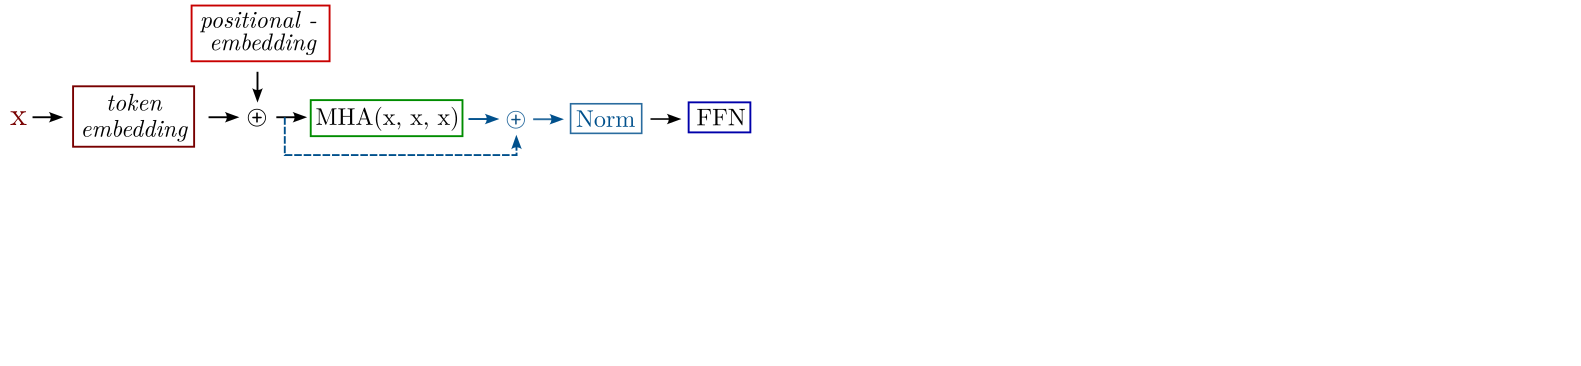</center></p><p style="text-align:center;"><em>Camada feed-forward.</em>

<font size=3>
    
> No artigo, a **função de ativação** $\sigma$ utilizada é a função $\text{ReLU}(x)=\max(0,\,x)$, mas implementações modernas utilizam sua versão aproximativa [$\text{GELU}$](https://arxiv.org/pdf/1606.08415v5). Esta função permite que pequenos valores negativos passem, a fim de "desengasgar" neurônios e trazer uma convergência mais rápida de redes muito profundas.

$$
    \text{GELU}(x) = \frac12 x \left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right] \approx 0.5\,x\left[1 + \tanh\left(\sqrt{\frac{2}{\pi}}\left(x + 0.044715\,x^3\right)\right)\right] \, .
$$

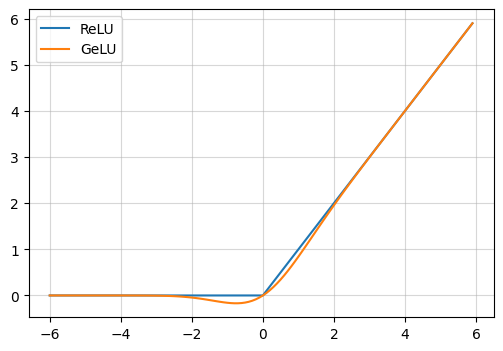

In [22]:
x_in = tf.range(-6, 6, 0.1)

plt.figure(figsize=(6, 4))
plt.plot(x_in, tf.nn.relu(x_in), label="ReLU")
plt.plot(x_in, tf.nn.gelu(x_in), label="GeLU")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

## **6. O bloco Codificador:**
<font size=3>

Agora, vamos criar uma nova classe (`EncoderLayer`) que encapsula todo o processo de codificação estudado.

<font size=3><center>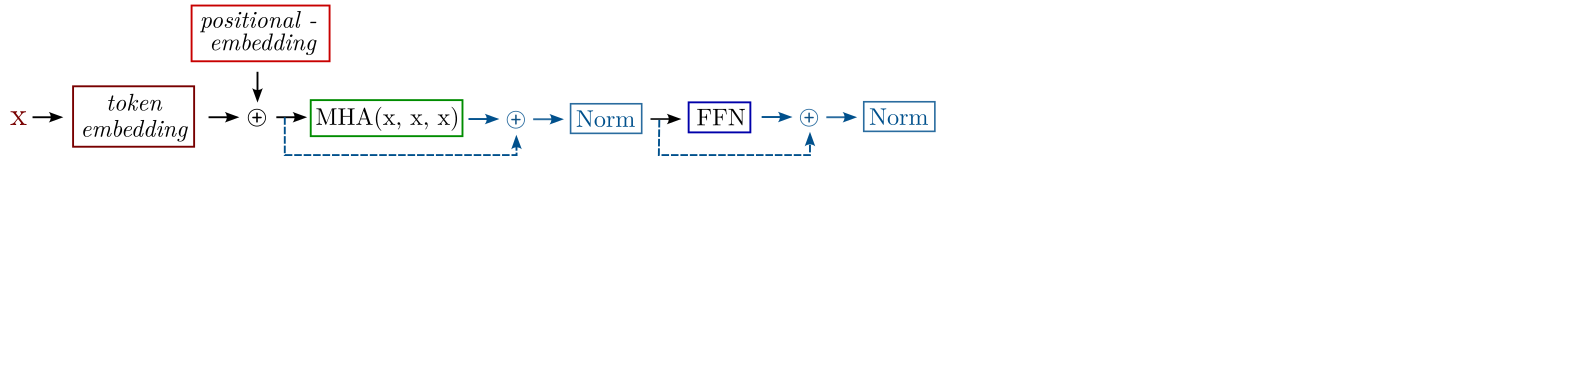</center></p><p style="text-align:center;"><em>A camada codificadora.</em>

In [23]:
from keras import Sequential

In [24]:
class EncoderLayer(layers.Layer):

    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        self.mha = MultiHeadAttention(embed_dim, num_heads)

        self.ffn = Sequential([layers.Dense(dense_dim, activation="gelu"),
                               layers.Dense(embed_dim)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        self.supports_masking = True

    def call(self, x, padding_mask=None):

        x += self.mha(x, x, x, mask=padding_mask)

        x = self.norm1(x)

        x += self.ffn(x)

        return self.norm2(x)



In [25]:
dense_dim = 128

LE = EncoderLayer(embed_dim, dense_dim, num_heads)

print(f"x-in: {x.shape}")

x = LE(x)

print(f"x-out:{x.shape}")

x-in: (1, 16, 32)
x-out:(1, 16, 32)


### **6.1 Empilhando camadas:**
<font size=3>

Com esta nova camada, podemos aprofunda ainda mais o processamento apenas empilhando várias delas em sequência, o que forma o **bloco codificador**.

<font size=3><center>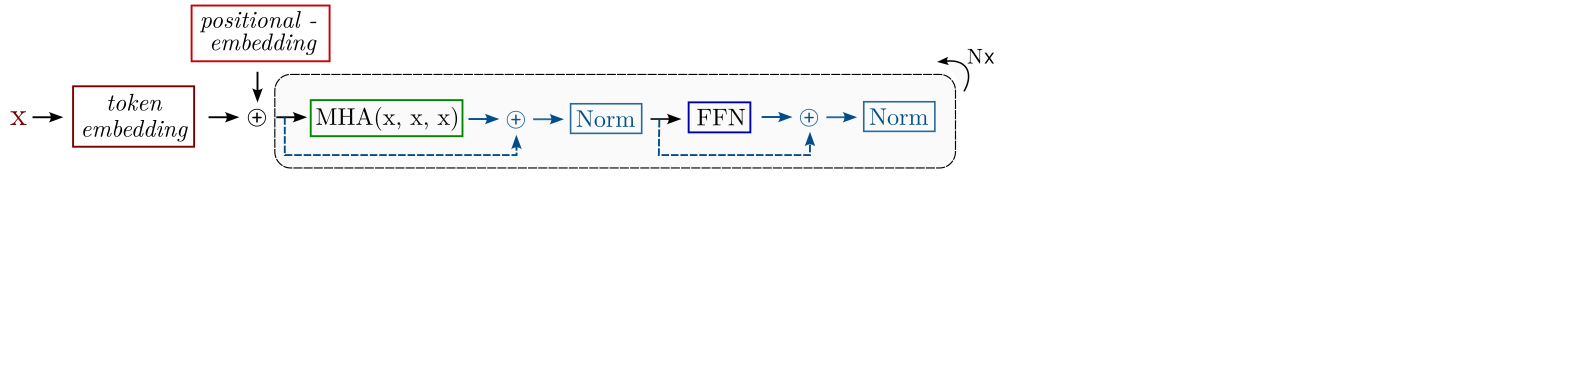</center></p><p style="text-align:center;"><em>O bloco codificador.</em>

In [26]:
n_layers = 3

EncoderBlock = Sequential([EncoderLayer(embed_dim, dense_dim, num_heads)
                           for _ in range(n_layers)])


In [27]:
print(f"x-in: {x.shape}")

x = EncoderBlock(x)

print(f"x-out:{x.shape}")

x-in: (1, 16, 32)
x-out:(1, 16, 32)


/Users/gilcesarf/git/repositories/imd/imd1107-202601/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'sequential_4' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## **7. O bloco Decodificador:**
<font size=3>

Enquanto o Codificador (*Encoder*) processa a frase de entrada (Português) de uma só vez para criar uma representação de contexto, o **Decodificador** (*Decoder*) tem a função de gerar a tradução (Inglês) passo a passo, palavra por palavra.

<font size=3>

O bloco decodificador possui uma estrutura similar ao codificador, mas com **duas diferenças fundamentais**:

1. **Autoatenção Mascarada (*Masked Self-Attention*):** Impede que o modelo "cole" olhando para as palavras futuras da frase alvo.
2. **Atenção Cruzada (*Cross-Attention*):** Uma camada extra que conecta o Decodificador ao Codificador.

### **7.1 A máscara causal:**
<font size=3>

Para treinar o Decodificador de forma eficiente, nós usamos uma técnica chamada **_Teacher Forcing_**: em vez de prever uma palavra, passar para a próxima e prever outra (o que seria lento e não paralelizável), nós entregamos a frase correta inteira de uma só vez para o modelo (ex: "I love AI").

No entanto, isso cria um problema de **vazamento de informação** (*data leakage*). Quando o modelo está na posição da palavra "I", ele deveria tentar prever a próxima palavra ("love"). Porém, através do mecanismo de auto-atenção, ele tem acesso matemático à palavra "love". Neste caso, a rede aprenderá a "colar" — ela simplesmente copiará a palavra da posição seguinte em vez de aprender a traduzir.

<font size=3><center>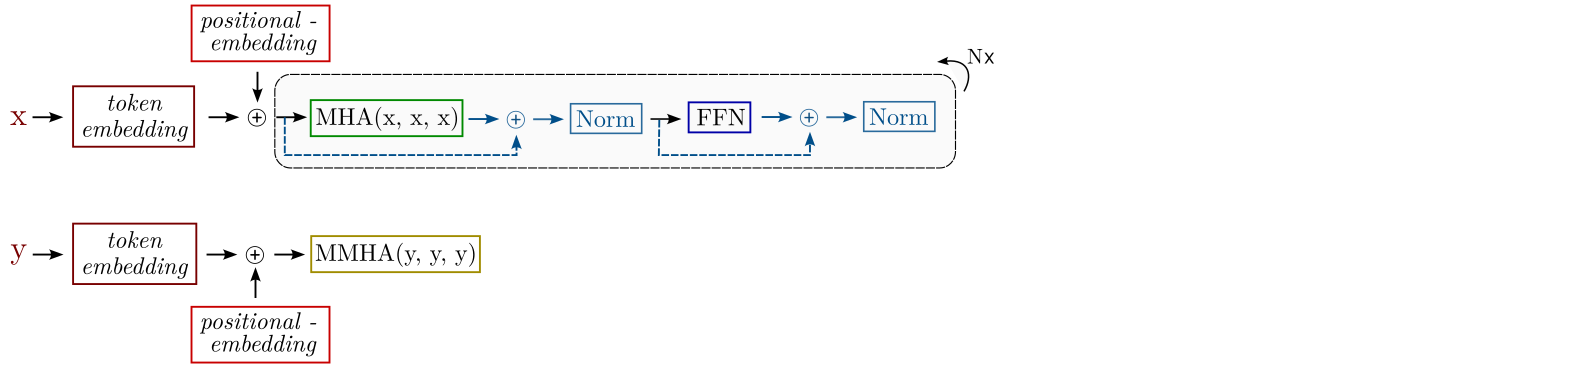</center></p><p style="text-align:center;"><em>Masked Multi-Head Attention (MMHA).</em>

<font size=3>
    
Como solução, usaremos o segundo tipo de máscara, a **máscara causal** (*causal mask*) $M$ para atuar diretamente na matriz $scores$, dentro da função Softmax,
$$
    \text{Attention}(Q,\, K,\, V) = \text{Softmax}\left(\frac{Q \cdot K^T}{\sqrt{d_k}} + M\right) \cdot V \, .
$$
Lembre-se que a matriz $scores = Q\cdot K^T/\sqrt{d_k}$ é um tipo de matriz de correlação *token* a *token* (semelhante ao *heatmap* plotado na subseção 3.4). Se definirmos $M \in \mathbb{R}^{L,\, L}$ como uma **matriz triangular inferior**, tal que
- para elemento visível $M_{ij} = 1$;
- e para elemento oculto $M_{ij} = 0$,

como por exemplo,
$$
M = \begin{bmatrix}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1
\end{bmatrix} \, ,
$$
a **atenção será nula** quando o elemento de $scores$ for $-\infty$. Assim, o efeito da máscara será "esconder" a sequência de *tokens* de cada linha da matriz, algo como:
$$
\begin{bmatrix}
\text{she} & \text{[mask]} & \text{[mask]} & \text{[mask]}\\
\text{she} & \text{surfs} & \text{[mask]} & \text{[mask]} \\
\text{she} & \text{surfs} & \text{very} & \text{[mask]} \\
\text{she} & \text{surfs} & \text{very} & \text{well}
\end{bmatrix}
$$

> **Lembrete:**
> - No caso acima, a auto-atenção calcula $Q$ e $K$ a partir da entrada $x$;
> - **Eixo X ($K$)** representa "*quem está sendo olhado*";
> - **Eixo Y ($Q$)** representa "*quem está olhando*";
> - Assim, a **atenção é nula** quando a marcara ocorrem em "quem está sendo olhado" ($K$).
   

In [28]:
# vamos simular a matriz weights mascarada:
text = "he learned how to surf very well before she started skateboarding even during her early childhood"

tokens = text.split()

# indexação:
ids = source_vec([text])

# vetorização:
x_vec = PE(ids)

# MHA sem máscara:
MHA = MultiHeadAttention(embed_dim, num_heads, return_weights=True)

_, weights_no_mask = MHA(x_vec, x_vec, x_vec, mask=None)

weights_no_mask.shape

TensorShape([1, 4, 16, 16])

In [29]:
# criando máscara:
mask = tf.linalg.band_part(tf.ones((max_len, max_len)), -1, 0)
mask = mask[tf.newaxis, tf.newaxis, :, :] # (1, 1, 20, 20)
mask[0, 0]

<tf.Tensor: shape=(16, 16), dtype=float32, numpy=
array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
 

In [30]:
_, weights_with_mask = MHA(x_vec, x_vec, x_vec, mask=mask)

weights_with_mask.shape

TensorShape([1, 4, 16, 16])

In [31]:
matrix1 = weights_no_mask[0, 0].numpy()
matrix2 = weights_with_mask[0, 0].numpy()

print("Soma dos elementos de cada linha da matrix weight com máscara:")
print(matrix2.sum(axis=1).round(4))

Soma dos elementos de cada linha da matrix weight com máscara:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


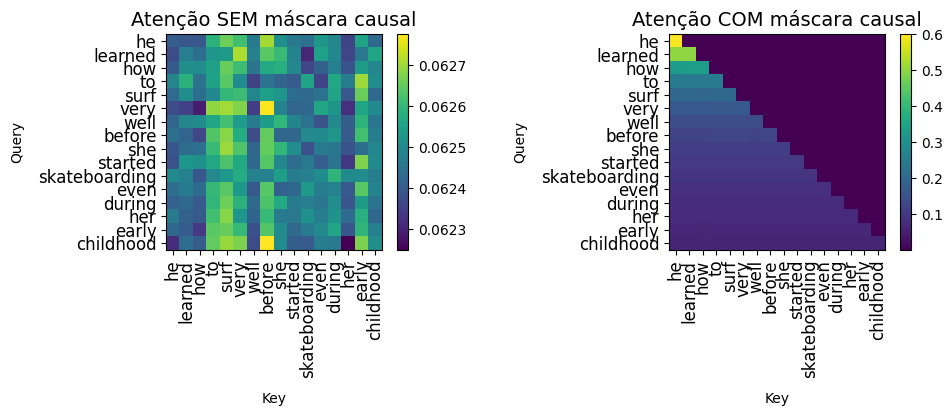

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cax1 = ax[0].matshow(matrix1, cmap='viridis')
ax[0].set_title("Atenção SEM máscara causal", fontsize=14)
fig.colorbar(cax1, ax=ax[0])

cax2 = ax[1].matshow(matrix2, cmap='viridis', vmin=0.001, vmax=0.6)
ax[1].set_title("Atenção COM máscara causal", fontsize=14)
fig.colorbar(cax2, ax=ax[1])

for a in ax:
    a.set_xticks(np.arange(len(tokens)))
    a.set_yticks(np.arange(len(tokens)))
    a.set_xticklabels(tokens, rotation=90, fontsize=12)
    a.set_yticklabels(tokens, fontsize=12)
    a.xaxis.set_ticks_position('bottom')
    a.set_xlabel("Key", labelpad=10)
    a.set_ylabel("Query", labelpad=10)

plt.tight_layout()
plt.show()

#### **7.1.1 Máscara combinada:**
<font size=3>

E se a nossa sentença tiver tamanho **menor** que `max_len`? Precisaremos de uma **máscara combinada**: *causal + padding mask*.

Considerando a sequência de tamanho 4:

<font size=2>

```python
 ["ela", "surfa", "bem", "[pad]"]
```
<br>

<font size=3>

A máscara mista teria o seguinte representação:
$$
\underbrace{\begin{bmatrix}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1
\end{bmatrix}}_\text{causal mask} +
\underbrace{\begin{bmatrix}
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 0
\end{bmatrix}}_\text{padding mask} \Rightarrow
\underbrace{\begin{bmatrix}
1 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 \\
1 & 1 & 1 & 0 \\
1 & 1 & 1 & 0
\end{bmatrix}}_\text{combined mask}
$$

> **Note** que o canto inferior direito, na máscara mista, que era 1 na causal, virou 0. Isso impede que o *token* [pad] atenda a si mesmo, o que é irrelevante para a saída.

Numericalmente, basta fazer:

<font size=2>

```python
    combined_mask = tf.minimum(causal_mask, padding_mask)

```
<br>

### **7.2 Atenção cruzada:**
<font size=3>

Se a auto-atenção mascarada é onde o Decodificador "*olha para o que já escreveu (em inglês)*", a **atenção cruzada** (*cross-attention*) busca correlacionar os dois idiomas *token* a *token*.

Diferente da autoatenção, aqui as entradas vêm de lugares diferentes:
 - **_Query_ ($Q$):** Vem do **Decodificador** — o que foi traduzido em inglês.
 - **_Key_ ($K$) e _value_ ($V$):** Vêm do **Codificador** — a frase original em português.

> **Analogia:** O Decodificador diz: *"Estou com a palavra 'love' ($Q$), existe algo na frase em português ($K$) relacionado a sentimento?"*. O Codificador responde: *"Sim, a palavra 'amo' ($V$)"*.

<font size=3><center>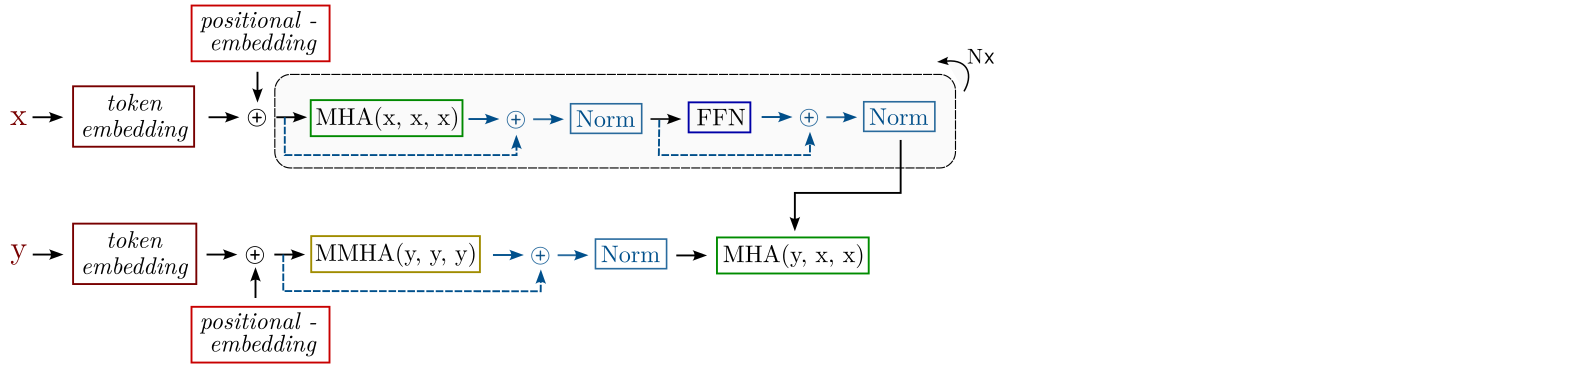</center></p><p style="text-align:center;"><em>Atenção cruzada.</em>

In [33]:
# vamos simular a matriz weights da atenção cruzada:
text_por, text_eng

('ela sabe andar de skate', '[start] she can skate [end]')

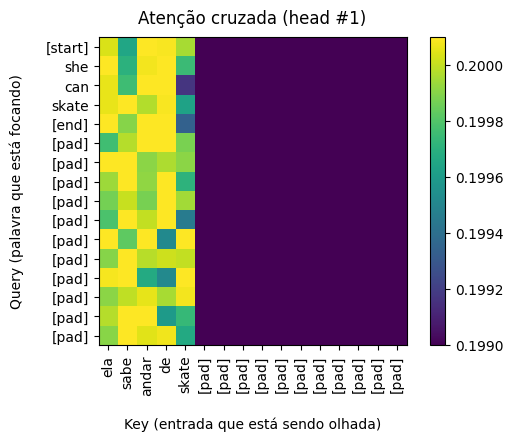

In [34]:
# tokenização para visualização dos eixos:
tokens_por = text_por.split()
real_len = len(tokens_por)

tokens_por += (max_len - real_len)*["[pad]"]

tokens_eng = text_eng.split()

assert real_len == len(tokens_eng)

tokens_eng += (max_len - real_len)*["[pad]"]

# indexação:
ids_eng = source_vec([text_eng])

# vetorização:
x_eng = PE(ids_eng)

# MHA sem máscara:
MHA = MultiHeadAttention(embed_dim, num_heads, return_weights=True)

_, weights_cross = MHA(x_eng, x_por, x_por, mask=padding_mask(ids_por))

# visualização:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

plt.title("Atenção cruzada (head #1)", pad=10)

cax = ax.matshow(weights_cross[0, 0], vmin=0.199, vmax=0.2001)
fig.colorbar(cax)

ax.set_xticks(range(max_len))
ax.set_yticks(range(max_len))
ax.set_xticklabels(tokens_por, rotation=90)
ax.set_yticklabels(tokens_eng)

ax.xaxis.set_ticks_position('bottom')

plt.xlabel("Key (entrada que está sendo olhada)", labelpad=15)
plt.ylabel("Query (palavra que está focando)", labelpad=15)
plt.show()

<font size=3>

>**Observe** na figura abaixo que, assim como o bloco codificador, o **bloco decodificador** apresenta uma **conexão residual** seguida de **normalização** após cada camada de processamento, que inclui uma rede **_feed-forward_** para apliar a extração de *features*.  

<font size=3><center>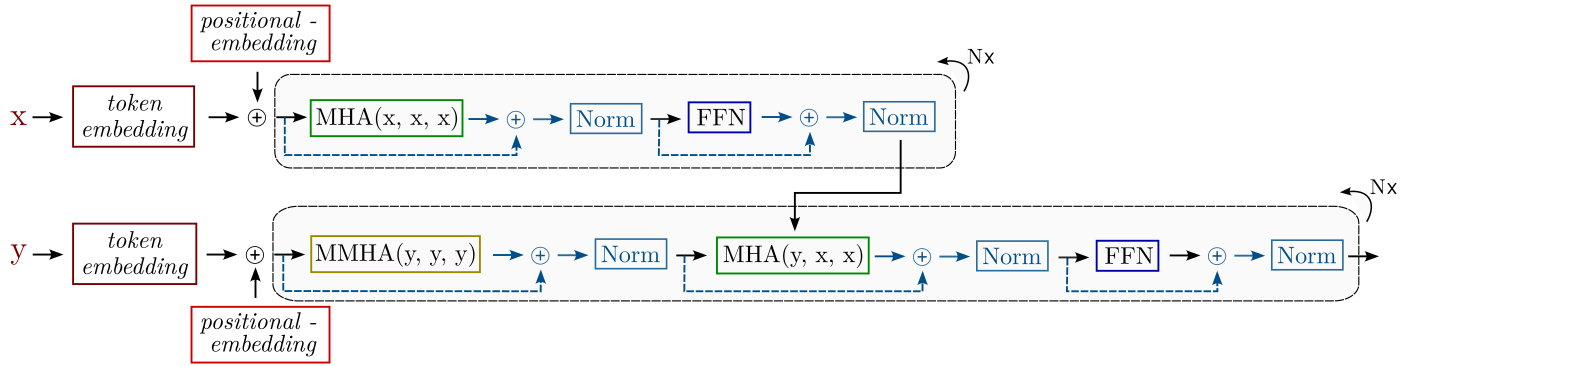</center></p><p style="text-align:center;"><em>O bloco decodificador.</em>

In [35]:
class DecoderLayer(layers.Layer):

    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads

        self.mha1 = MultiHeadAttention(embed_dim, num_heads)

        self.mha2 = MultiHeadAttention(embed_dim, num_heads)

        self.ffn = Sequential([layers.Dense(dense_dim, activation="gelu"),
                               layers.Dense(embed_dim)])

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)

        self.supports_masking = True


    def call(self, y, x, padding_mask=None, causal_mask=None):

        '''
        Seguindo a imagem acima, definimos:
         - x: saída do Encoder (fluxo principal);
         - y: saída do Decoder (memória contextual).
        '''

        y += self.mha1(y, y, y, mask=padding_mask)

        y = self.norm1(y)

        y += self.mha2(y, x, x, mask=causal_mask)

        y = self.norm2(y)

        y += self.ffn(y)

        return self.norm3(y)



In [36]:
# simulando a entrada y:
y = tf.random.uniform(x.shape)

layer = DecoderLayer(embed_dim, dense_dim, num_heads)

print(f"y-in: {y.shape}")

y = layer(y, x)

print(f"y-out:{y.shape}")

y-in: (1, 16, 32)
y-out:(1, 16, 32)


<font size=3>

> **Observação:** O bloco do decodificador, com a sequência de `DecoderLayer`, será desenvolvida na estrutura final do modelo.

## **8. O modelo _Transformer_:**
<font size=3>

Para finalizar a construção da arquitetura, precisamos modelar a saída a fim de implementar toda a estrutura.

### **8.1 A saída do modelo:**
<font size=3>

Até este momento, nosso modelo manipulou representações vetoriais densas (*embeddings*). A saída do último bloco do Decodificador é um tensor de formato `(batch-size, max-len, embed-dim)`. No entanto, nós não queremos vetores; queremos palavras. Queremos saber: **qual é a probabilidade de cada palavra do vocabulário inglês ser a próxima?**

Para isso, precisamos de duas operações finais simples:
 1. **Camada linear (projeção final):** Uma camada densa que expande o vetor de tamanho `embed-dim` para o tamanho do vocabulário de destino `vocab_size`.
 2. **Softmax:** Transforma esses números brutos em uma distribuição de probabilidade.
     

<font size=3><center>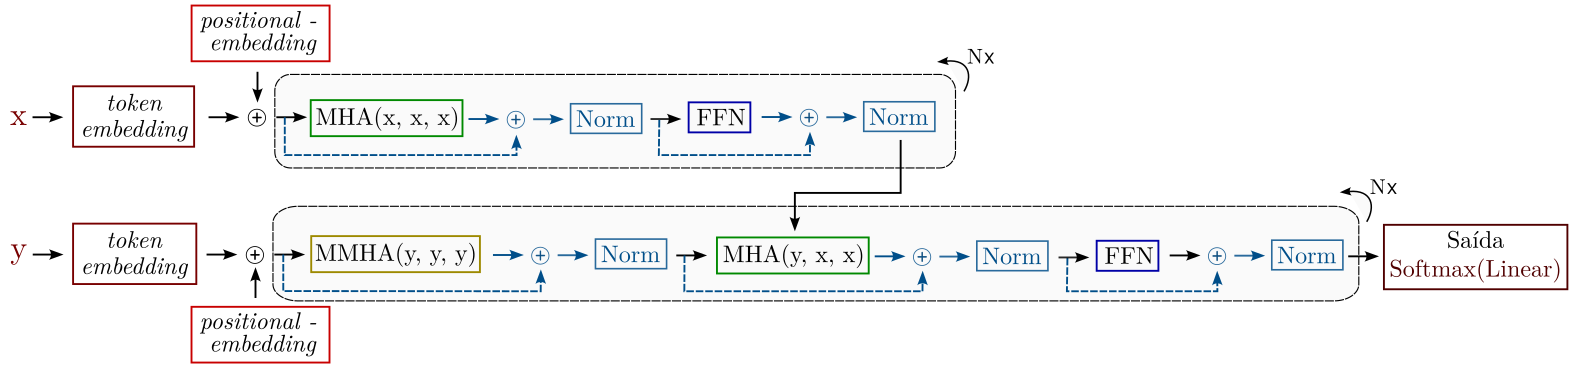</center></p><p style="text-align:center;"><em>Arquitetura Transformer.</em>

### **8.2 A arquitetura _Transformer_:**
<font size=3>

Por fim, segue a arquitetura completa do modelo **_Transformer_:**

In [37]:
import keras

In [38]:
class Transformer(keras.Model):

    def __init__(self, max_len, vocab_size, embed_dim, dense_dim, num_heads, n_layers):
        super().__init__()

        # vetorizadores:
        self.encoder_embedding = PositionalEmbedding(max_len, vocab_size, embed_dim)
        self.decoder_embedding = PositionalEmbedding(max_len, vocab_size, embed_dim)

        # blocos de encoder e decoder:
        self.encoder_block = [EncoderLayer(embed_dim, dense_dim, num_heads)
                              for _ in range(n_layers)]

        self.decoder_block = [DecoderLayer(embed_dim, dense_dim, num_heads)
                              for _ in range(n_layers)]

        # camada de saída
        self.output_layer = layers.Dense(vocab_size, activation="softmax")


    def call(self, inputs):

        if isinstance(inputs, dict):
            source = inputs["source"]
            target = inputs["target"]
        else:
            source, target = inputs

        # Encoder:
        enc_padding_mask = self.padding_mask(source)

        x = self.encoder_embedding(source)

        for layer in self.encoder_block:
            x = layer(x, enc_padding_mask)

        # Decoder:
        dec_padding_mask = self.padding_mask(target)
        causal_mask = self.causal_mask(tf.shape(target)[1])
        dec_combined_mask = tf.minimum(dec_padding_mask, causal_mask)

        y = self.decoder_embedding(target)

        for layer in self.decoder_block:
            y = layer(y, x, dec_combined_mask, enc_padding_mask)

        # output:
        return self.output_layer(y)


    @staticmethod
    def padding_mask(seq):
        seq = tf.cast(tf.math.not_equal(seq, 0), tf.float32)

        return seq[:, tf.newaxis, tf.newaxis, :]


    @staticmethod
    def causal_mask(seq_len):
        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

        return mask[tf.newaxis, tf.newaxis, :, :]


In [39]:
# definindo o modelo:
model = Transformer(max_len, vocab_size, embed_dim, dense_dim, num_heads, n_layers)

# definindo um batch de dados de entrada:
example_batch = next(iter(train_dset))
inputs, targets = example_batch

# processando a saída:
output = model(inputs)

print(f"x:{x.shape}, y:{y.shape}\n")
print(f"output:{output.shape}")

x:(1, 16, 32), y:(1, 16, 32)

output:(64, 16, 5000)


## **9. O treinamento do modelo:**
<font size=3>

Diferente de redes neurais simples, o Transformer exige um agendador de taxa de aprendizado específico e funções de perda customizadas para ignorar os zeros do preenchimento.

### **9.1 O agendador de _learning rate_:**
<font size=3>
    
O artigo define que a taxa de aprendizado $lr$ deve aumentar linearmente durante os primeiros passos (*warmup steps*) e depois diminuir proporcionalmente à raiz quadrada inversa do número do passo, dado por
$$
    lr = d_{model}^{-1/2}\cdot\min\left(\text{step\_num}^{-1/2},\, \text{step\_num}\cdot\text{warmup\_steps}^{-1/2}\right) \, .
$$

Isso evita que os gradientes explodam no início (quando os pesos são aleatórios) e permite um ajuste fino mais tarde.

In [40]:
from keras.optimizers import schedules

In [41]:
class CustomSchedule(schedules.LearningRateSchedule):

    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()

        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        arg1 = tf.math.rsqrt(step)
        arg2 = step*self.warmup_steps**-1.5

        return tf.math.rsqrt(self.d_model)*tf.math.minimum(arg1, arg2)


### **9.2 Função de perda e métricas:**
<font size=3>
    
Como nossos dados contêm muito *padding*, se usarmos a função de perda padrão, o modelo aprenderá rapidamente que "chutar zero" é uma ótima estratégia para diminuir o erro médio. Precisamos zerar o erro onde o alvo real é *padding*.

In [42]:
from keras import losses

In [43]:
def masked_loss(real, pred):

    real = tf.cast(real, tf.int64)

    loss = tf.keras.losses.sparse_categorical_crossentropy(real, pred)

    mask = tf.cast(tf.math.not_equal(real, 0), tf.float32)

    loss *= mask

    return tf.reduce_sum(loss)/tf.reduce_sum(mask)


<font size=3>

A mesma lógica se aplica à acurácia. Se tivermos 90 zeros e 10 palavras, e o modelo chutar tudo zero, ele teria 90% de acurácia "falsa".

In [44]:
def masked_accuracy(real, pred):

    pred = tf.argmax(pred, axis=2)

    corrects = tf.equal(tf.cast(real, tf.int64), tf.cast(pred, tf.int64))

    mask = tf.math.not_equal(real, 0)

    # apenas consideramos acertos onde a máscara é True:
    corrects = tf.math.logical_and(corrects, mask)

    mask = tf.cast(mask, dtype=tf.float32)
    corrects = tf.cast(corrects, dtype=tf.float32)

    return tf.reduce_sum(corrects)/tf.reduce_sum(mask)


### **9.3 Compilando o modelo:**
<font size=3>
    
Agora juntamos tudo para preparar o Transformer para o treinamento.

In [45]:
# definindo o scheduler:
learning_rate = CustomSchedule(d_model=embed_dim)

# definindo o otimizador de acordo com o artigo:
optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# compilando:
model.compile(optimizer=optimizer, loss=masked_loss, metrics=[masked_accuracy])


### **9.4 O _fit_ do modelo:**
<font size=3>
    
Agora que temos nossa arquitetura, função de perda e otimizador configurados, chegamos ao momento de unir tudo e chamar o `.fit()`.

<font size=2>

```python
report = model.fit(train_dset, validation_data=val_dset, epochs=2)
```

<font size=3>
<br>
    
>**Observação:** o treinamento completo do modelo será feito no próximo _notebook_.


## **10. Inferência:**
<font size=3>

Até agora, durante o treinamento, utilizamos o **Teacher Forcing**. Nós entregávamos ao Decoder a resposta correta (deslocada) e perguntávamos: *"Dada a frase em português e essas palavras em inglês que já apareceram, qual é a próxima?"*.

<font size=3><center>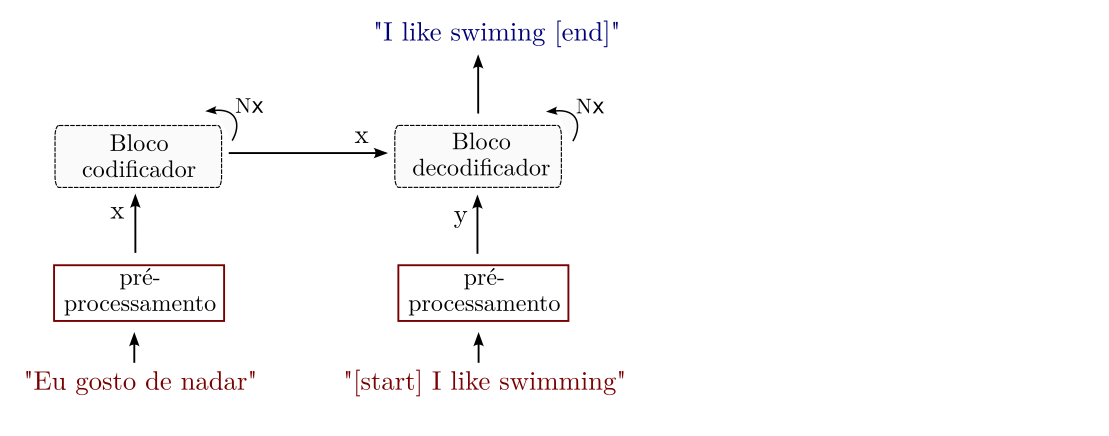</center></p><p style="text-align:center;"><em>Treinamento do modelo.</em>

<font size=3>

Na inferência (uso real), nós **não temos** a resposta em inglês. O modelo precisa gerar a própria resposta, palavra por palavra.

### **10.1 Paralelismo vs. autoregressão:**
<font size=3>
    
1. **Treino (paralelo):** Graças às máscaras e ao fato de termos o `target` completo, o Transformer processa a frase inteira de uma vez.

2. **Inferência (sequencial/autoregressiva):** O modelo gera uma palavra. Essa palavra é "colada" na entrada e usada para gerar a segunda palavra. A segunda é colada para gerar a terceira, e assim por diante. É um loop.


<font size=3><center>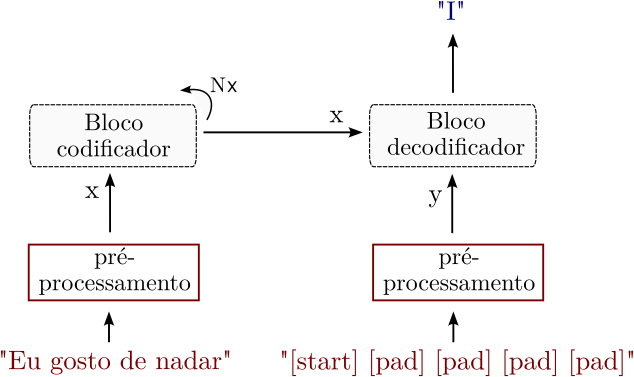</center></p><p style="text-align:center;"><em>Predição: primeira iteração.</em>

<font size=3><center>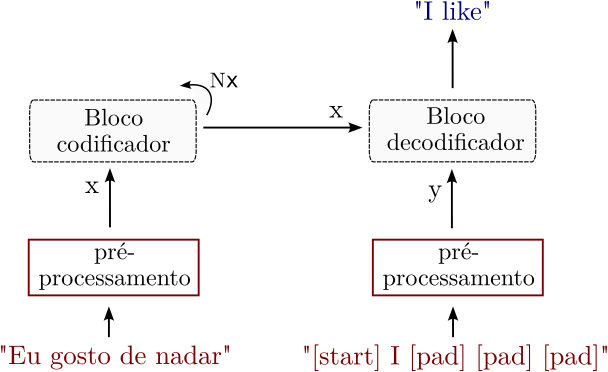</center></p><p style="text-align:center;"><em>Predição: segunda iteração.</em>

### **10.2 O algoritmo _greedy search_:**
<font size=3>
    
Existem várias formas de gerar texto (_Beam Search_, _Top-K_, _Nucleus Sampling_). Para esta aula, usaremos a mais didática: **_greedy search_**.

A lógica é simples:
1. O modelo calcula a probabilidade para todos os *tokens* da lista vocabulário.
2. Nós escolhemos **apenas a de maior probabilidade** (o `argmax`).
3. Ignoramos as outras possibilidades e seguimos em frente.


### **10.3 Implementação do tradutor:**
<font size=3>
    
Vamos criar uma função `translate` que encapsula todo esse processo.

In [46]:
def translate(sentence, model, tokenizer_pt, tokenizer_en, max_len=40):

    sentence = tf.convert_to_tensor([sentence])
    encoder_input = tokenizer_pt(sentence)

    try:
        start_token = tokenizer_en.get_vocabulary().index('start')
        end_token = tokenizer_en.get_vocabulary().index('end')

    except ValueError:
        start_token = tokenizer_en.get_vocabulary().index('[start]')
        end_token = tokenizer_en.get_vocabulary().index('[end]')

    output_array = tf.constant([[start_token]], dtype=tf.int64)

    for i in range(max_len):

        predictions = model((encoder_input, output_array), training=False)

        predictions = predictions[:, -1:, :]

        predicted_id = tf.argmax(predictions, axis=-1)

        output_array = tf.concat([output_array, predicted_id], axis=-1)

        if int(predicted_id) == end_token:
            break


    text_tokens = []
    vocab = tokenizer_en.get_vocabulary()

    for token in output_array[0]:
        word = vocab[int(token)]
        if word not in ['start', 'end', '[start]', '[end]', '', '[UNK]']:
            text_tokens.append(word)

    return " ".join(text_tokens)

sentence = "eu gosto de ler livros"
translation = translate(sentence, model, source_vec, target_vec, max_len)

print(f"Original: {sentence}\n")
print(f"Tradução: {translation}")

Original: eu gosto de ler livros

Tradução: return press leaving day winds day animal leaving press sentences oven twelve oven press day dangerous


<font size=3>
<br>
    
>Acima, temos um exemplo de uma péssima tradução!\
>Isso ocorre porque nosso modelo não passou pela fase de treinamento.\
>Faremos essa etapa no próximo notebook.\
>Até já!